# Detección de anomalias usando Autoencoders

**Contexto:**

Usaremos el conjunto de datos Numenta Anomaly Benchmark (NAB). Este proporciona series de tiempo artificiales que contienen períodos anómalos de comportamiento etiquetados. Los datos están ordenados, tienen marcas de tiempo y son métricas de un solo valor.

Usaremos el archivo `art_daily_small_noise.csv` para el entrenamiento y el archivo `art_daily_jumpsup.csv` para las pruebas. 

La simplicidad de este conjunto de datos nos permite demostrar la detección de anomalías de manera efectiva.

# Librerias

In [1]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from matplotlib import pyplot as plt

# Cargamos datos

In [2]:
master_url_root = "https://raw.githubusercontent.com/numenta/NAB/master/data/"

df_small_noise_url_suffix = "artificialNoAnomaly/art_daily_small_noise.csv"
df_small_noise_url = master_url_root + df_small_noise_url_suffix
df_small_noise = pd.read_csv(
    df_small_noise_url, parse_dates=True, index_col="timestamp"
)

df_daily_jumpsup_url_suffix = "artificialWithAnomaly/art_daily_jumpsup.csv"
df_daily_jumpsup_url = master_url_root + df_daily_jumpsup_url_suffix
df_daily_jumpsup = pd.read_csv(
    df_daily_jumpsup_url, parse_dates=True, index_col="timestamp"
)

In [3]:
# Entrenamiento / Training
print(df_small_noise.head())

# Prueba / Test
print(df_daily_jumpsup.head())

                         value
timestamp                     
2014-04-01 00:00:00  18.324919
2014-04-01 00:05:00  21.970327
2014-04-01 00:10:00  18.624806
2014-04-01 00:15:00  21.953684
2014-04-01 00:20:00  21.909120
                         value
timestamp                     
2014-04-01 00:00:00  19.761252
2014-04-01 00:05:00  20.500833
2014-04-01 00:10:00  19.961641
2014-04-01 00:15:00  21.490266
2014-04-01 00:20:00  20.187739


# Visualizacion de datos

#### Series sin anomalías

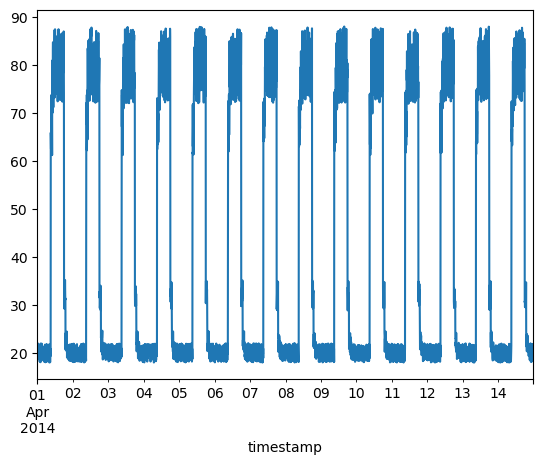

In [4]:
fig, ax = plt.subplots()
df_small_noise.plot(legend=False, ax=ax)
plt.show()

#### Series con anomalías

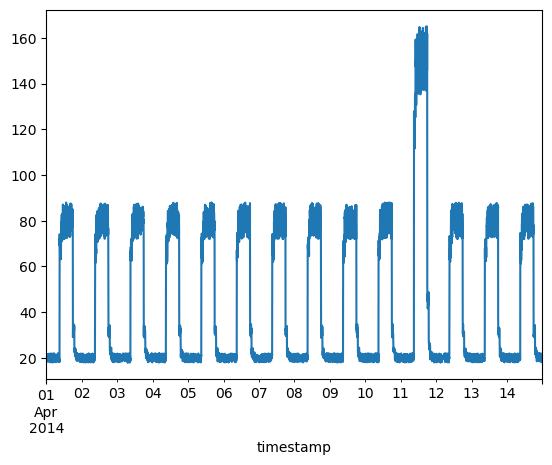

In [5]:
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
plt.show()

# Preprocesamiento de los datos

Obtenemos los valores del archivo de datos de la serie de tiempo de entrenamiento y normalizamos los datos de `value`. Tenemos un `value` cada 5 minutos durante 14 días.

- 24 * 60 / 5 = **288 pasos de tiempo por día**
- 288 * 14 = **4032 puntos de datos** en total"

In [6]:
# Normalize and save the mean and std we get, for normalizing test data.

training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std
print("Número de ejemplos de entrenamiento:", len(df_training_value))

Número de ejemplos de entrenamiento: 4032


#### Creación de secuencias

In [8]:
TIME_STEPS = 288
# Create sequences combining TIME_STEPS contiguous data values from the training data.

# Generated training sequences for use in the model.
def create_sequences(values, time_steps=TIME_STEPS):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape)

Training input shape:  (3745, 288, 1)


# Construcción del modelo.

We will build a convolutional reconstruction autoencoder model. The model will take input of shape (batch_size, sequence_length, num_features) and return output of the same shape. In this case, sequence_length is 288 and num_features is 1

In [11]:
model = tf.keras.Sequential(
    [
        layers.Input(shape=(x_train.shape[1], x_train.shape[2])),
        layers.Conv1D(
            filters=32, 
            kernel_size=7, 
            padding="same",
            strides=2,
            activation="relu"
        ),
        layers.Dropout(rate=0.2),
        layers.Conv1D(
            filters=16,
            kernel_size=7,  
            padding="same",
            activation="relu",
            strides=2,
        ),
        layers.Conv1DTranspose(
            filters=16,
            kernel_size=7,
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Dropout(rate=0.2),
        layers.Conv1DTranspose(
            filters=32, 
            kernel_size=7, 
            padding="same",
            strides=2,
            activation="relu",
        ),
        layers.Conv1DTranspose(
            filters=1, 
            kernel_size=7, 
            padding="same"),
    ]
)

model.compile(optimizer = optimizers.Adam(learning_rate=0.001), loss="mse")
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 144, 32)           256       
                                                                 
 dropout_2 (Dropout)         (None, 144, 32)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 72, 16)            3600      
                                                                 
 conv1d_transpose_3 (Conv1D  (None, 144, 16)           1808      
 Transpose)                                                      
                                                                 
 dropout_3 (Dropout)         (None, 144, 16)           0         
                                                                 
 conv1d_transpose_4 (Conv1D  (None, 288, 32)           3616      
 Transpose)                                           

# Entrenamiento del modelo

Please note that we are using `x_train` as both the input and the target since this is a reconstruction model.

In [12]:
history = model.fit(
    x_train,
    x_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", 
            patience=5, 
            mode="min"
        )
    ],
)

Epoch 1/50


2026-01-12 20:02:04.399190: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-01-12 20:02:04.455149: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


27/27 [==============================] - 3s 34ms/step - loss: 0.5034 - val_loss: 0.0924
Epoch 2/50
27/27 [==============================] - 0s 11ms/step - loss: 0.0792 - val_loss: 0.0403
Epoch 3/50
27/27 [==============================] - 0s 11ms/step - loss: 0.0552 - val_loss: 0.0319
Epoch 4/50
27/27 [==============================] - 0s 11ms/step - loss: 0.0446 - val_loss: 0.0276
Epoch 5/50
27/27 [==============================] - 0s 12ms/step - loss: 0.0388 - val_loss: 0.0248
Epoch 6/50
27/27 [==============================] - 0s 11ms/step - loss: 0.0346 - val_loss: 0.0220
Epoch 7/50
27/27 [==============================] - 0s 11ms/step - loss: 0.0312 - val_loss: 0.0206
Epoch 8/50
27/27 [==============================] - 0s 12ms/step - loss: 0.0283 - val_loss: 0.0183
Epoch 9/50
27/27 [==============================] - 0s 14ms/step - loss: 0.0260 - val_loss: 0.0185
Epoch 10/50
27/27 [==============================] - 0s 14ms/step - loss: 0.0241 - val_loss: 0.0184
Epoch 11/50
27/27 [=

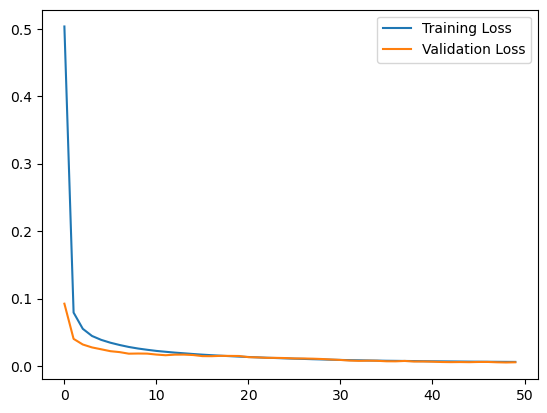

In [13]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

# Detectando anomalías.

Detectaremos anomalías determinando qué tan bien nuestro modelo puede reconstruir los datos de entrada.

1. Calcular la pérdida **MAE** en las muestras de entrenamiento.
2. Encontrar el valor máximo de la pérdida **MAE**. Este es el peor desempeño de nuestro modelo al intentar reconstruir una muestra. Usaremos este valor como el `umbral` para la detección de anomalías.
3. Si la pérdida de reconstrucción para una muestra es mayor que este valor `umbral`, entonces podemos inferir que el modelo está observando un patrón con el que no está familiarizado. Etiquetaremos esta muestra como una `anomalía`.

118/118 [==============================] - 1s 5ms/step


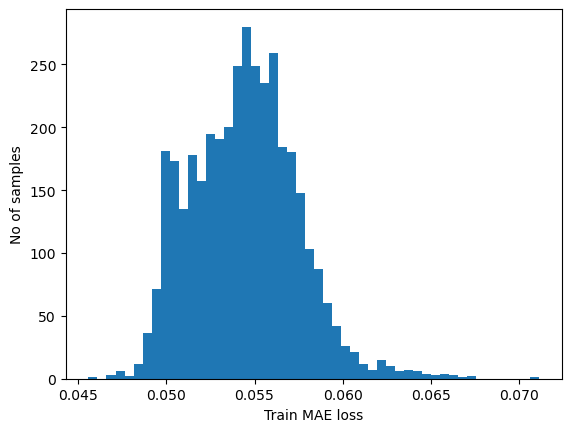

Reconstrucción del umbral de error:  0.0711723115313745


In [14]:
# Obtenemos el MAE.
x_train_pred = model.predict(x_train)
train_mae_loss = np.mean(np.abs(x_train_pred - x_train), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

threshold = np.max(train_mae_loss)
print("Reconstrucción del umbral de error: ", threshold)

## Comparar reconstrucción

Veamos cómo nuestro modelo ha reconstruido la primera muestra. Esta corresponde a los **288 pasos de tiempo del día 1** de nuestro conjunto de entrenamiento.

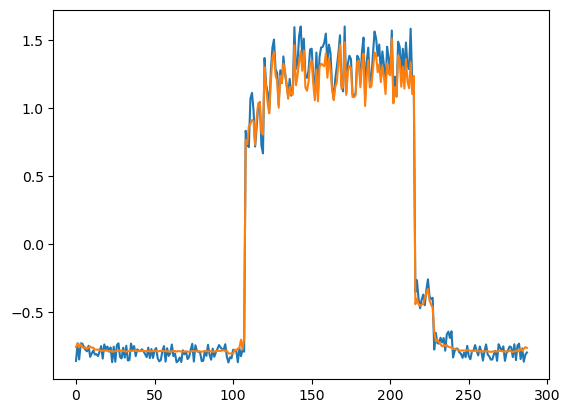

In [15]:
# Checking how the first sequence is learnt
plt.plot(x_train[0])
plt.plot(x_train_pred[0])
plt.show()

## Preparando el conjunto de datos de TEST

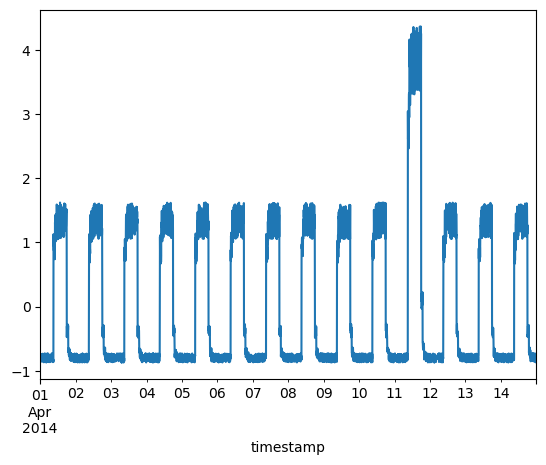

Test input shape:  (3745, 288, 1)
118/118 [==============================] - 0s 3ms/step


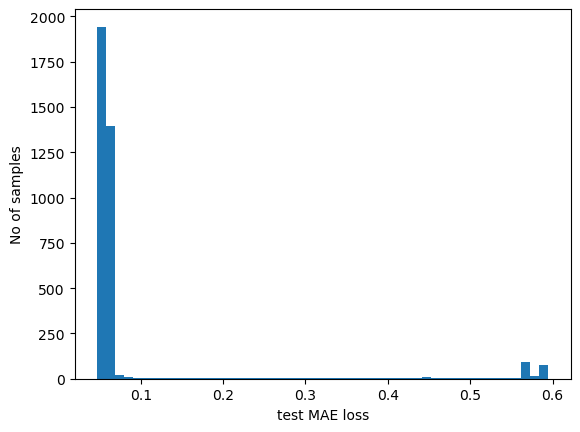

Number of anomaly samples:  401
Indices of anomaly samples:  (array([ 793,  794, 1945, 1946, 2521, 2699, 2701, 2702, 2703, 2704, 2705,
       2706, 2707, 2708, 2709, 2710, 2711, 2712, 2713, 2714, 2715, 2716,
       2717, 2718, 2719, 2720, 2721, 2722, 2723, 2724, 2725, 2726, 2727,
       2728, 2729, 2730, 2731, 2732, 2733, 2734, 2735, 2736, 2737, 2738,
       2739, 2740, 2741, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2749,
       2750, 2751, 2752, 2753, 2754, 2755, 2756, 2757, 2758, 2759, 2760,
       2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771,
       2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782,
       2783, 2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793,
       2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804,
       2805, 2806, 2807, 2808, 2809, 2810, 2811, 2812, 2813, 2814, 2815,
       2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824, 2825, 2826,
       2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834, 2835, 2

In [16]:
df_test_value = (df_daily_jumpsup - training_mean) / training_std
fig, ax = plt.subplots()
df_test_value.plot(legend=False, ax=ax)
plt.show()

# Create sequences from test values.
x_test = create_sequences(df_test_value.values)
print("Test input shape: ", x_test.shape)

# Get test MAE loss.
x_test_pred = model.predict(x_test)
test_mae_loss = np.mean(np.abs(x_test_pred - x_test), axis=1)
test_mae_loss = test_mae_loss.reshape((-1))

plt.hist(test_mae_loss, bins=50)
plt.xlabel("test MAE loss")
plt.ylabel("No of samples")
plt.show()

# Detect all the samples which are anomalies.
anomalies = test_mae_loss > threshold
print("Number of anomaly samples: ", np.sum(anomalies))
print("Indices of anomaly samples: ", np.where(anomalies))

## Graficamos ahora las anomalías.

Ahora ya conocemos las muestras de los datos que son anomalías. Con esto, encontraremos las `timestamps` correspondientes a partir de los datos originales de prueba. Usaremos el siguiente método para hacerlo:

Supongamos que `time_steps = 3` y tenemos `10 valores de entrenamiento.` Nuestro `x_train` se verá así:

- 0, 1, 2
- 1, 2, 3
- 2, 3, 4
- 3, 4, 5
- 4, 5, 6
- 5, 6, 7
- 6, 7, 8
- 7, 8, 9

Excepto los valores iniciales y finales (time_steps - 1), todos los demás aparecerán en time_steps muestras distintas. 

Por lo tanto, si sabemos que las muestras `[(3, 4, 5), (4, 5, 6), (5, 6, 7)]` son anomalías, podemos decir que el punto de dato 5 es una anomalía.

In [19]:
anomalous_data_indices = []
for data_idx in range(TIME_STEPS - 1, len(df_test_value) - TIME_STEPS + 1):
    if np.all(anomalies[data_idx - TIME_STEPS + 1 : data_idx]):
        anomalous_data_indices.append(data_idx)

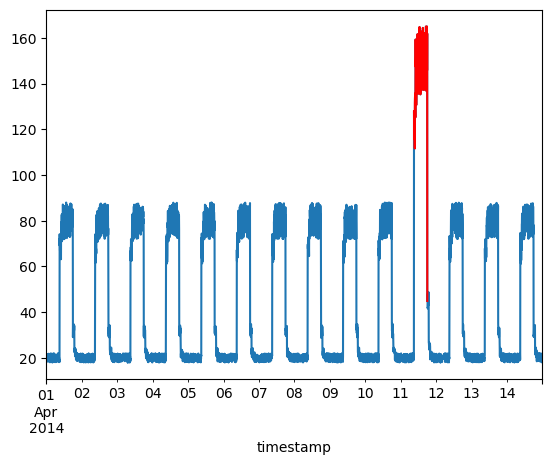

In [20]:
df_subset = df_daily_jumpsup.iloc[anomalous_data_indices]
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
df_subset.plot(legend=False, ax=ax, color="r")
plt.show()